In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load dataset
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
cols = ["user_id", "item_id", "rating", "timestamp"]
df = pd.read_csv(url, sep="\t", names=cols)

print(df.head())
print(df.shape)

# split
train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Train size:", train.shape)
print("Test size:", test.shape)

   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596
(100000, 4)
Train size: (80000, 4)
Test size: (20000, 4)


We use the MovieLens 100K dataset, which contains 100,000 ratings from 943 users on 1,682 items. Each record consists of a user ID, item ID, and a rating from 1 to 5.

We randomly split the dataset into training (80%) and test (20%) sets.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# create user mean from train
user_mean = train.groupby("user_id")["rating"].mean()

# prediction function
def predict_user_mean(row):
    return user_mean.loc[row.user_id]

# apply on test
test["pred_baseline"] = test.apply(predict_user_mean, axis=1)

# evaluate
rmse = np.sqrt(mean_squared_error(test["rating"], test["pred_baseline"]))
print("Baseline RMSE:", rmse)

Baseline RMSE: 1.041744757128949


As a baseline, we use the user mean model, where each user's rating is predicted by their average rating in the training set. This captures user-specific rating bias but ignores item characteristics and interactions between users and items.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Build user-item matrix
# -----------------------------
user_item_matrix = train.pivot_table(index="user_id", columns="item_id", values="rating")

user_mean = user_item_matrix.mean(axis=1)
global_mean = train["rating"].mean()

# mean-centered matrix
user_item_centered = user_item_matrix.sub(user_mean, axis=0)

# fill NaN with 0 for cosine similarity
user_item_centered_filled = user_item_centered.fillna(0)

# -----------------------------
# 2. Compute similarity
# -----------------------------
user_similarity = cosine_similarity(user_item_centered_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# -----------------------------
# 3. Prediction function
# -----------------------------
def predict_user_knn_fast(row, k=20):
    target_user = row["user_id"]
    target_item = row["item_id"]

    if target_user not in user_item_matrix.index:
        return global_mean

    if target_item not in user_item_matrix.columns:
        return user_mean.get(target_user, global_mean)

    rated_users = user_item_matrix[target_item].dropna().index
    rated_users = [u for u in rated_users if u != target_user]

    if len(rated_users) == 0:
        return user_mean.get(target_user, global_mean)

    sims = user_similarity_df.loc[target_user, rated_users]
    sims = sims[sims > 0].sort_values(ascending=False).head(k)

    if len(sims) == 0:
        return user_mean.get(target_user, global_mean)

    neighbor_ratings = user_item_matrix.loc[sims.index, target_item]
    neighbor_means = user_mean.loc[sims.index]

    pred = user_mean[target_user] + np.dot(sims.values, (neighbor_ratings - neighbor_means).values) / np.sum(np.abs(sims.values))

    return pred

# -----------------------------
# 4. Evaluate
# -----------------------------
test2 = test.copy()
test2["pred_knn"] = test2.apply(lambda row: predict_user_knn_fast(row, k=20), axis=1)
test2["pred_knn"] = test2["pred_knn"].clip(1, 5)

rmse_knn = np.sqrt(mean_squared_error(test2["rating"], test2["pred_knn"]))
print("Improved fast User-User kNN RMSE:", rmse_knn)

Improved fast User-User kNN RMSE: 0.9357798341391308


We implemented an improved user-user kNN collaborative filtering model as a stronger personalized recommender. Unlike the baseline user-mean approach, this model uses information from similar users to make predictions. We first built a user-item matrix from the training data and computed each user’s mean rating. Then we mean-centered the ratings and used cosine similarity to measure similarity between users.

For each test example, we identified users who had rated the target item, selected the top-\(k\) most similar neighbors, and predicted the rating using a weighted average of neighbors’ rating deviations from their own means. The prediction was then shifted back by adding the target user’s mean rating. If no valid neighbors were available, we used fallback values such as the user mean or global mean.

This version is more personalized than the baseline because it incorporates collaborative preference patterns across users. At the same time, it remains simple and computationally practical. By using mean-centered ratings, it also provides a more reasonable similarity measure than directly comparing raw ratings.

In [ ]:
#Evaluation
def precision_recall_at_k(predictions, pred_col, k=10, threshold=4.0):

    #Group predictions by user
    user_est_true = {}
    for _, row in predictions.iterrows():
        u = row['user_id']
        user_est_true.setdefault(u, []).append((row[pred_col], row['rating']))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():
        #Sort user ratings by estimated value
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        #Number of relevant items
        n_rel = sum((true_r >= threshold) for (est, true_r) in user_ratings)

        #Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, true_r) in user_ratings[:k])

        #Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        #Precision@K: Proportion of recommended items that are relevant
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        #Recall@K: Proportion of relevant items that are recommended
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return precisions, recalls

#Run the evaluation
test['pred_knn'] = test.apply(lambda row: predict_user_knn_fast(row, k=10), axis=1)

p_base, r_base = precision_recall_at_k(test, 'pred_baseline', k=10)
p_knn, r_knn = precision_recall_at_k(test, 'pred_knn', k=10)

#Average results over all users
avg_precision_base = sum(prec_val for prec_val in p_base.values()) / len(p_base)
avg_recall_base = sum(rec_val for rec_val in r_base.values()) / len(r_base)

avg_precision_knn = sum(prec_val for prec_val in p_knn.values()) / len(p_knn)
avg_recall_knn = sum(rec_val for rec_val in r_knn.values()) / len(r_knn)

print("Base: ")
print(f"Precision@10: {avg_precision_base:.4f}")
print(f"Recall@10: {avg_recall_base:.4f}\n")

print("KNN: ")
print(f"Precision@10: {avg_precision_knn:.4f}")
print(f"Recall@10: {avg_recall_knn:.4f}")

Base: 
Precision@10: 0.1363
Recall@10: 0.1306

KNN: 
Precision@10: 0.6251
Recall@10: 0.3331


The Precision@10 of 0.6251 shows that out of a typical top 10 list, 6 of them woudl be hits (4 or 5 stars). The Recall@10 shows that the model captures 33% of all the movies a user liked within the top 10 list. These are strong metrics for a memory-based collaborative filtering approach, especially considering the sparsity of the MovieLens 100K dataset. Because a user's total number of liked movies often far exceeds the 10 slots available in a recommendation window, achieving a recall of over 30% suggests the model is accurately prioritizing the most relevant items for the user's top-level ranking.

Sparsity-
The user-item matrix is only ~6% filled (100k ratings across ~1.6M possible cells). To compute cosine similarity, you fill the blanks with 0, which makes unrated items look like neutral preferences. This means two users with similar taste but little rating overlap will appear dissimilar, shrinking the neighbor pool and forcing frequent fallback to the user mean.

Popularity Bias-
Similarity is dominated by widely-rated movies. Two users who both loved the same obscure film barely register as similar compared to two users who both watched popular blockbusters. This quietly skews recommendations toward mainstream items, which also artificially inflates your Precision@10 since popular items are just easier to predict as "relevant."

Cold-Start-
New users or items have little to no data, so the model has nothing to work with. Your code handles this with fallbacks (global mean, user mean), but those are just educated guesses — no real personalization. This is a fundamental limitation of memory-based collaborative filtering: it can only recommend well for users and items it's already seen enough of.

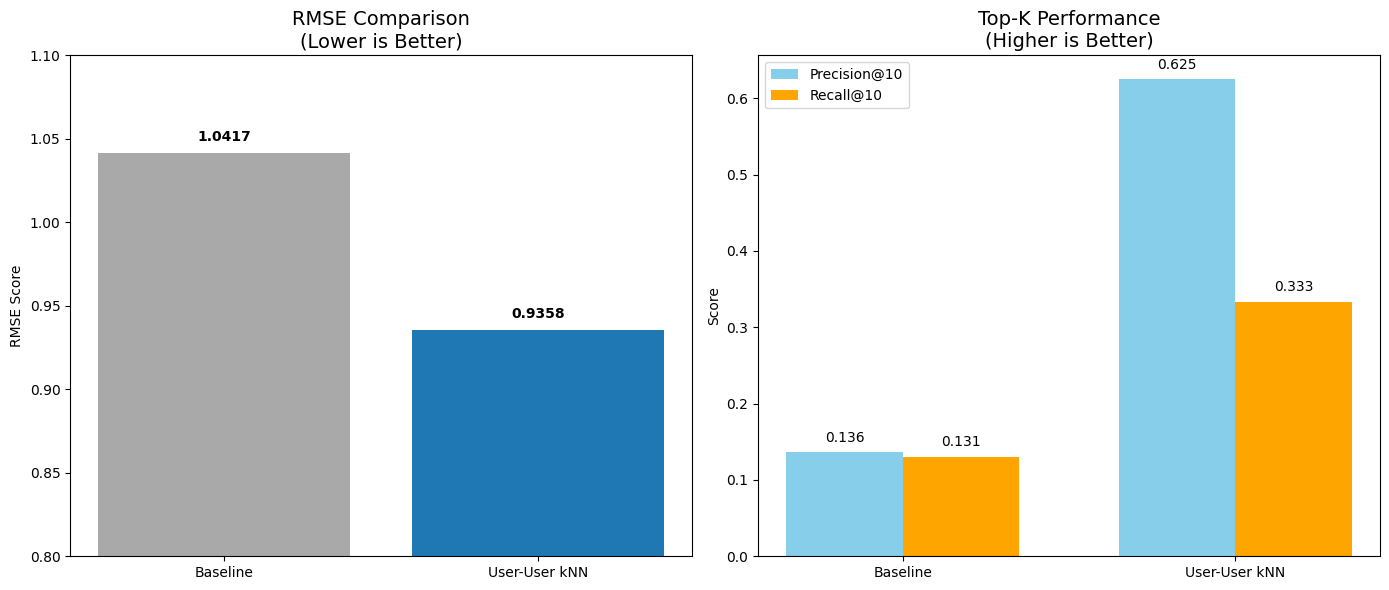

In [ ]:
import matplotlib.pyplot as plt

#Data from your results
models = ['Baseline', 'User-User kNN']
rmse_values = [1.0417, 0.9358]
precision_values = [0.1363, 0.6251]
recall_values = [0.1306, 0.3331]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#RMSE
bars1 = ax1.bar(models, rmse_values, color=['#A9A9A9', '#1f77b4'])
ax1.set_title('RMSE Comparison\n(Lower is Better)', fontsize=14)
ax1.set_ylabel('RMSE Score')
ax1.set_ylim(0.8, 1.1)  # Zoomed in to show the difference
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

#Precision & Recall @ 10
x = np.arange(len(models))
width = 0.35
bars2_p = ax2.bar(x - width/2, precision_values, width, label='Precision@10', color='skyblue')
bars2_r = ax2.bar(x + width/2, recall_values, width, label='Recall@10', color='orange')

ax2.set_title('Top-K Performance\n(Higher is Better)', fontsize=14)
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()

#Add value labels for Precision/Recall
for bar in bars2_p:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')
for bar in bars2_r:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom')

plt.tight_layout()